# Intervalos de Confianza para la Media

## Objetivo

Estimar parámetros poblacionales de las variables de interés mediante intervalos de confianza (IC).

Se analizarán:

- Horas de sueño
- Nivel de estrés

Se calcularán IC con niveles de confianza 90%, 95% y 99% y se observará el efecto del tamaño de muestra sobre el ancho del intervalo.

## Variables de interés

- Horas de sueño (continua)
- Nivel de estrés (discreta)

In [2]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

data = pd.read_csv("/content/drive/MyDrive/habitos_saludables_estudiantes.csv")
data

Mounted at /content/drive


,edad,genero,horas_sueno,horas_ejercicio,comida_rapida_semana,estres,Prom_academico
0,18,Masculino,6.9,2.0,0,6,5.98
1,25,Femenino,5.6,1.2,2,10,6.31
2,28,Femenino,7.6,0.7,1,8,4.88
3,20,Masculino,6.3,1.2,3,3,5.20
4,28,Femenino,6.1,3.1,4,10,5.49
...,...,...,...,...,...,...,...
145,27,Masculino,5.7,3.0,3,10,5.59
146,27,Masculino,6.9,6.5,3,2,6.40
147,29,Masculino,7.7,3.6,1,3,6.12
148,26,Masculino,5.0,3.3,2,1,5.60


In [3]:
#Función para calcular intervalo de confianza
def intervalo_confianza_media(variable, confianza=0.95):
    n = len(variable)
    media = variable.mean()
    std = variable.std(ddof=1)
    z = stats.norm.ppf(1 - (1 - confianza)/2)
    margen_error = z * (std / np.sqrt(n))
    return media - margen_error, media + margen_error

In [4]:
#Intervalos de confianza para horas de sueño
niveles_confianza = [0.90, 0.95, 0.99]
sueno = data["horas_sueno"]

for conf in niveles_confianza:
    ic = intervalo_confianza_media(sueno, conf)
    print(f"IC {int(conf*100)}% horas de sueño: {ic[0]:.2f} - {ic[1]:.2f}")

IC 90% horas de sueño: 6.27 - 6.62
IC 95% horas de sueño: 6.24 - 6.66
IC 99% horas de sueño: 6.17 - 6.72


In [5]:
#Intervalos de confianza para nivel de estrés
estres = data["estres"]

for conf in niveles_confianza:
    ic = intervalo_confianza_media(estres, conf)
    print(f"IC {int(conf*100)}% nivel de estrés: {ic[0]:.2f} - {ic[1]:.2f}")

IC 90% nivel de estrés: 4.87 - 5.69
IC 95% nivel de estrés: 4.80 - 5.76
IC 99% nivel de estrés: 4.64 - 5.92


In [ ]:
#Comparación de tamaños de muestra

Se puede observar cómo el tamaño de la muestra afecta el ancho del intervalo.  
A menor tamaño de muestra → mayor incertidumbre → IC más amplio.  
A mayor tamaño de muestra → menor incertidumbre → IC más estrecho.

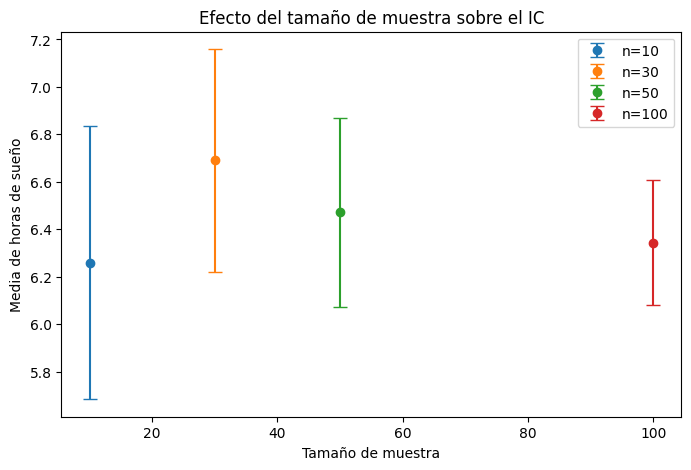

In [6]:
tamaños_muestra = [10, 30, 50, 100]
confianza = 0.95

plt.figure(figsize=(8,5))

for n in tamaños_muestra:
    muestra = sueno.sample(n, replace=False)
    ic = intervalo_confianza_media(muestra, confianza)
    plt.errorbar(n, muestra.mean(), yerr=(ic[1]-muestra.mean()), fmt='o', capsize=5, label=f"n={n}")

plt.xlabel("Tamaño de muestra")
plt.ylabel("Media de horas de sueño")
plt.title("Efecto del tamaño de muestra sobre el IC")
plt.legend()
plt.show()

## Conclusiones

1. Se calcularon intervalos de confianza para las variables horas de sueño y nivel de estrés.
2. Los IC muestran el rango donde esperamos que se encuentre la media poblacional con distintos niveles de confianza.
3. A mayor nivel de confianza (99%), los intervalos son más amplios, reflejando mayor certeza sobre la estimación.
4. A mayor tamaño de muestra, el margen de error disminuye y los IC se vuelven más estrechos, aumentando la precisión.
5. Estos resultados sientan la base para pruebas de hipótesis en la siguiente lección, ya que permiten comparar la media observada con valores hipotéticos poblacionales.